<a href="https://colab.research.google.com/github/shatanshu3006/ML-Projects/blob/main/Benchmarking_TTFT%2C_TPOT_%26_KV_Caching_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#set the runtime to T4 GPU before starting any of this
!pip install -q vllm openai matplotlib requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72

### Fixing CUDA Version Mismatch

The previous error indicates a `RuntimeError` where PyTorch and TorchAudio were compiled with different CUDA versions. The system has CUDA 13.0, but TorchAudio was compiled for CUDA 12.8. To resolve this, we need to reinstall `torch` and `torchaudio` specifically for CUDA 13.0.

In [19]:
# Uninstall existing torch and torchaudio to prevent conflicts
!pip uninstall -y torch torchaudio

# Install torch and torchaudio compatible with CUDA 13.0
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 56.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.5/526.5 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.0 MB/s eta 0:00:00


In [14]:
import subprocess
import time
import requests

print("Starting vLLM server with Qwen2.5-1.5B-Instruct in background...")

Starting vLLM server with Qwen2.5-1.5B-Instruct in background...


In [20]:
import subprocess
import time
import requests
import select # For non-blocking IO

print("Starting vLLM server with Qwen2.5-1.5B-Instruct in background...")

# Launch vLLM server with automatic Prefix Caching enabled
vllm_process = subprocess.Popen(['python3', '-m', 'vllm.entrypoints.openai.api_server',
                                 '--model', 'Qwen/Qwen2.5-1.5B-Instruct',
                                  '--enable-prefix-caching',
                                  '--port', '8000',
                                  '--gpu-memory-utilization', '0.85'],
                                 stdout=subprocess.PIPE,
                                 stderr=subprocess.STDOUT, # Redirect stderr to stdout for unified logging
                                 text=True, # Decode as text
                                 bufsize=1, # Line-buffered output
                                 universal_newlines=True # For compatibility
                                )

print("⏳ Waiting for vLLM to download weights and allocate VRAM...")
url = "http://localhost:8000/v1/models"

# Poll until server endpoint responds and continuously print logs
while True:
  # Check if vLLM process has terminated
  if vllm_process.poll() is not None:
    print("❌ vLLM process terminated unexpectedly!")
    # Read any remaining output if the process died
    for line in vllm_process.stdout.readlines():
      print(f"[vLLM LOG - final] {line.strip()}")
    break # Exit the loop as the process is dead

  # Check for new output from vLLM process in a non-blocking way
  reads = [vllm_process.stdout.fileno()]
  ready = select.select(reads, [], [], 0.1) # Timeout 0.1 seconds to avoid blocking

  if ready[0]:
    line = vllm_process.stdout.readline()
    if line:
      print(f"[vLLM LOG] {line.strip()}")

  # Check server status
  try:
    res=requests.get(url)
    if res.status_code==200:
      print("✅ vLLM Server is UP and READY for requests!")
      break # Exit the loop once the server is ready
  except requests.exceptions.ConnectionError:
    # Server not ready yet, continue polling and printing logs
    pass
  except Exception as e:
    print(f"⚠️ An unexpected error occurred while checking server status: {e}")
    pass
  time.sleep(1) # Reduced sleep to check logs and server status more frequently

Starting vLLM server with Qwen2.5-1.5B-Instruct in background...
⏳ Waiting for vLLM to download weights and allocate VRAM...
[vLLM LOG] /usr/local/lib/python3.13/dist-packages/vllm/entrypoints/openai/api_server.py:24: DeprecationWarning: `vllm.entrypoints.openai.api_server` is deprecated and will likely beunsupported in a future version. Use the corresponding function from `vllm.entrypoints.launchers` instead.
[vLLM LOG] warnings.warn(
[vLLM LOG] /usr/local/lib/python3.13/dist-packages/vllm/entrypoints/openai/api_server.py:51: DeprecationWarning: The `python -m vllm.entrypoints.openai.api_server` command is deprecated and may be removed in a future release. Please use `vllm server` instead.
[vLLM LOG] warnings.warn(
[vLLM LOG] (APIServer pid=10761) INFO 09-15 20:56:35 [api_utils.py:347]
[vLLM LOG] (APIServer pid=10761) INFO 09-15 20:56:35 [api_utils.py:347]        █     █     █▄   ▄█
[vLLM LOG] (APIServer pid=10761) INFO 09-15 20:56:35 [api_utils.py:347]  ▄▄ ▄█ █     █     █ ▀▄▀ █  ver

In [7]:
!nvidia-smi

Tue Sep 15 20:41:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
import time
from openai import OpenAI

# Initialize client pointing to local vLLM instance
client = OpenAI(base_url="http://localhost:8000/v1", api_key="token-not-needed")
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

def measure_inference(prompt_text:str , label:str):
  print(f"\n==========================================")
  print(f" 🧪 Running: {label}")
  print(f"========================================")

  start_time=time.perf_counter()

  # Enable streaming to capture individual token arrival timestamps
  response=client.chat.completions.create(
      model=MODEL_NAME,
      messages=[{"role":"user", "content":prompt_text}],
      temperature=0.0,
      stream=True
  )

  ttft=None
  token_timestamps=[]
  generated_text=""

  for chunk in response:
    now = time.perf_counter()
    if chunk.choices and chunk.choices[0].delta.content: # Corrected access
      delta=chunk.choices[0].delta.content
      generated_text+=delta

      if ttft is None:
        # Time to First Token (End of Prefill Phase)
        ttft=(now-start_time) * 1000 #convert to ms

      else:
        #inter token timestamp (decode phase loop)
        token_timestamps.append(now)

  total_time=time.perf_counter()-start_time
  num_tokens=len(token_timestamps) + (1 if ttft else 0)

  # Calculate TPOT (average ms per token during streaming)
  if len(token_timestamps)>1:
    gaps=[token_timestamps[i]-token_timestamps[i-1] for i in range(1,len(token_timestamps))]
    tpot_ms=(sum(gaps)/(len(gaps))) * 1000
  else:
    tpot_ms=0.0

  print(f"TTFT (Prefill Delay): {ttft:.2f} ms")
  print(f"TPOT (Decode Token Gap): {tpot_ms:.2f} ms/token")
  print(f"Total Output Tokens: {num_tokens}")
  print(f"Total Duration: {total_time:.2f} s")

  return {
      "label": label,
      "ttft_ms": ttft,
      "tpot_ms": tpot_ms,
      "tokens": num_tokens,
      "total_time_s": total_time
  }

results =[]

# --- EXPERIMENT 1: Short vs. Long Prompt (Observe TTFT scaling) ---
short_p = "What is the capital of France?"
long_p = "Analyze the following context:\n" + ("The quick brown fox jumps over the lazy dog. " * 300) + "\nSummarize the key takeaways."

results.append(measure_inference(short_p, "1A. Short Prompt (Small Prefill)"))
results.append(measure_inference(long_p, "1B. Long Prompt (Heavy Prefill)"))

# --- EXPERIMENT 2: KV / Prefix Caching (Cold vs Warm Cache) ---
shared_prefix = "System Context:\n" + ("You are an expert AI infrastructure engineer. " * 200)

results.append(measure_inference(shared_prefix + "\nQuestion 1: Explain GPUs.", "2A. Cold Cache (Full Prefill)"))
results.append(measure_inference(shared_prefix + "\nQuestion 2: Explain VRAM.", "2B. Warm Cache (Reused KV Cache)"))


 🧪 Running: 1A. Short Prompt (Small Prefill)
TTFT (Prefill Delay): 37.22 ms
TPOT (Decode Token Gap): 18.81 ms/token
Total Output Tokens: 7
Total Duration: 0.17 s

 🧪 Running: 1B. Long Prompt (Heavy Prefill)
TTFT (Prefill Delay): 85.41 ms
TPOT (Decode Token Gap): 18.33 ms/token
Total Output Tokens: 61
Total Duration: 1.20 s

 🧪 Running: 2A. Cold Cache (Full Prefill)
TTFT (Prefill Delay): 54.54 ms
TPOT (Decode Token Gap): 17.11 ms/token
Total Output Tokens: 225
Total Duration: 3.90 s

 🧪 Running: 2B. Warm Cache (Reused KV Cache)
TTFT (Prefill Delay): 54.98 ms
TPOT (Decode Token Gap): 17.30 ms/token
Total Output Tokens: 364
Total Duration: 6.35 s


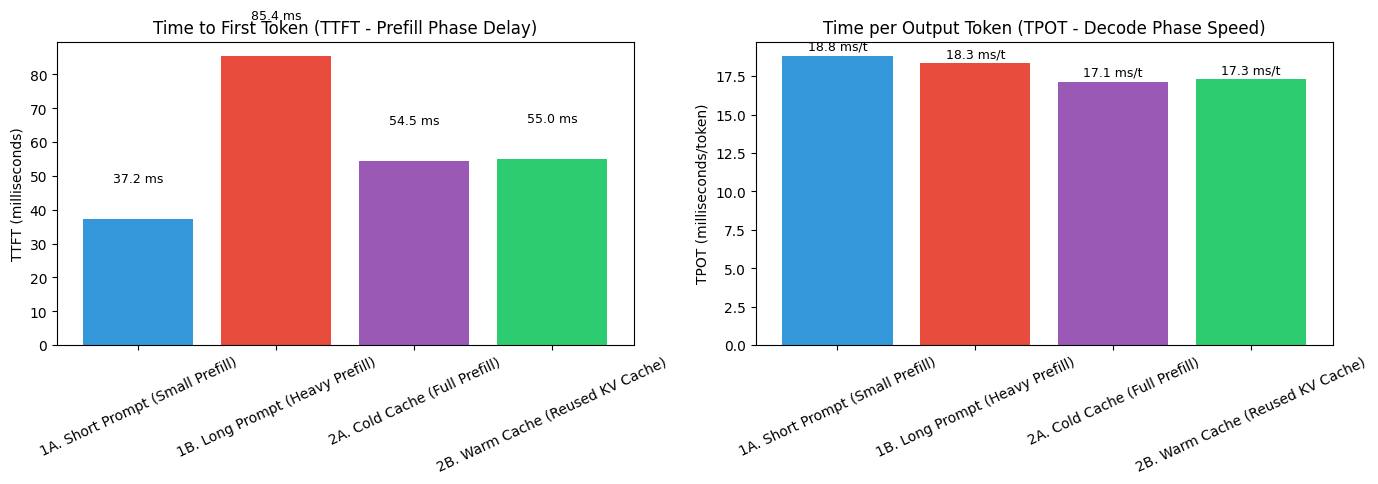

In [27]:
import matplotlib.pyplot as plt
# Extract metrics for plotting
labels = [r["label"] for r in results]
ttfts = [r["ttft_ms"] for r in results]
tpots = [r["tpot_ms"] for r in results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Time to First Token (TTFT)
bars1 = ax1.bar(labels, ttfts, color=['#3498db', '#e74c3c', '#9b59b6', '#2ecc71'])
ax1.set_title("Time to First Token (TTFT - Prefill Phase Delay)")
ax1.set_ylabel("TTFT (milliseconds)")
ax1.tick_params(axis='x', rotation=25)
for bar in bars1:
  yval = bar.get_height()
  ax1.text(bar.get_x() + bar.get_width()/2, yval + 10, f"{yval:.1f} ms", ha='center', va='bottom', fontsize=9)

# Chart 2: Time per Output Token (TPOT)
bars2 = ax2.bar(labels, tpots, color=['#3498db', '#e74c3c', '#9b59b6', '#2ecc71'])
ax2.set_title("Time per Output Token (TPOT - Decode Phase Speed)")
ax2.set_ylabel("TPOT (milliseconds/token)")
ax2.tick_params(axis='x', rotation=25)
for bar in bars2:
  yval = bar.get_height()
  ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval:.1f} ms/t", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()